# TripleSumm Architecture


In [1]:
# bu colab'te TripleSumm mimarisinin baştan sona inşa edeceğiz.

Bir frame dizisinin model içerisindeki yolculuğuna bakalım:

**1) Başlangıç - projeksiyonlar ve zenginleştirme**: Üç modalitenin feature'ları (2048 - 768 - 768 ) ayrı Linear katmanlarla 128-d ortak uzaya çekilir ve her birine LayerNorm uygulanır. (Normalizasyon).
Daha sonra her token'a iki kimlik bilgisi toplanır:
1) sinusoidal temporal PE (dizide ben nerdeyim?)
2) öğrenilebilir modality embedding (ben hangi modalitedeyim?)

Ayrıca bir de 4. dizi ortaya çıkar: **fusion dizisi**. Bu fusion dizisi üç modalitenin birleşiminden türetilen, sonradan "soru soran" rolünü üstlenecek olan dizidir.

**2) MST - Multi Scale Temporal Block**: Dört dizi de kendi içerisinde zamansal ilişkiyi öğrenir, fakat modaliteler birbirini henüz görmez. Bu block şu soruyu cevaplar: **Bu frame, zaman içindeki komşularıyla birlikte düşünüldüğünde ne anlama geliyor ?**

Adım adım düşünecek olursak, encoderdan çıkan feature'lar zamanlarak olarak hiçbirşey bilmezler. Örneğin InceptionV3 her frame'i tek başına görüp encode etti. 47sn vektörü 46. veya 48. saniyeden habersiz olarak. Fakat o frame'nin önemi tek kareden okunamaz. Bunun içim bağlam gerekir. Önem skorlamasına girmeden önce her frame'in vektörüne çevrende neler olup bittiğinin bilgisi işlenmesi gerekiyor. MST bu işlemi yapar.

Bunu yaptığı mekanizması ise **Windowed self-attention**: Klasik self-attention'da her frame tüm frameler ile konuşur. N sayıda frame olduğunu düşünürsek, N^2 karşılaştırma olur. Bu da hem işlem maliyeti açısından pahalı ve gereksizdir. WSA ise, her frame'in yalnızca ±w komşusuyla konuşmasına izin verir. Maliyer N*w düşer ve attention local context'e odaklanır.

**Multi-scale işlemi nedir?**: Bu ±w'lik pencere katman katman büyür. Küçük pencere boyutu detayı görebilir fakat genel anlamı kaçırır. Büyük pencere boyutu ise detayı kaçırabilir. Pencerenin katman katman büyümesi sayesinde etkin görüş alanı bileşik büyür. Son katmana gelindiğinde her frame hem mikro hem de makro bağlamı sindirmiş olur. Örn. 4 katman, pencereler 5 → 15 → 45 → global. İlk katman mikro hareketi işler (spikerin jest değişimi), sonrakiler giderek genişler (diyalog kalıbı → sahne geçişi → programın bütün akışı). Kritik incelik: 2. katman w=15 ile çalışırken girdisi zaten 1. katmandan geçmiş vektörler — yani her vektör ±5'lik bağlamı çoktan yutmuş durumda.

**3) CMF - Cross Modal Fusion Block**: MST'den çıkan diziler hala birbirlerine yabancıdır. MST sonrası elimizde zenginleşmiş 4 dizi var. CMF'nin cevapladığı soru ise şudur: **Bu saniyede üç modalitenin söyledikleri birleştirildiğinde ne çıkıyor — ve hangisine ne kadar kulak vermeliyim?**

CMF'nin mekanizması ise Fusion token'in soru sorduğu cross attentiondur.
Burada:

    Query: yalnız fusion token. "Bu anın özeti olmaya çalışıyorum — kimden ne almalıyım?

    Key/Value: yalnız üç modalite tokeni. Vitrinler ve içerikler onlar.

Q * K benzerlikleri softmax'ten geçince 3 sayı çıkar. o saniyenin modalite ağırlıkları - örneğin %20 visual, %70 text, %10 audio gibi.

Kısaca Cross-attention'da yalnız fusion güncellenir, Zamansal ilişki kurmaz (MST'nin işi) ve modalite token'larını güncellemez.

**MST -> CMF çifti 2 kez tekrarlanır.**

**3) Head**:  Son fusion temsili Linear(128→192) → GELU → Dropout → LayerNorm → Linear(192→1) → Sigmoid ile frame başına 0-1 skora iner.


In [2]:
import torch
import torch.nn as nn

torch.manual_seed(31)

# batch_size: aynı anda modele kaç örnek verileceği
# seq_len: her örneğin uzunluğu - 12 kelimelik cümle veya 12 frame
# d_model: Her bir karenin (veya kelimenin) bilgisayarın anlayacağı dilde ifade edildiği özellik (feature) vektörünün uzunluğu.
batch_size, seq_len, d_model = 2, 12, 128
X = torch.randn(batch_size, seq_len, d_model) # giriş verisi

q_proj = nn.Linear(d_model, d_model, bias=False)
k_proj = nn.Linear(d_model, d_model, bias=False)
v_proj = nn.Linear(d_model, d_model, bias=False)

# nn.Linear katmanlar, içinde eğitim sırasında güncellenecek ağırlıkları tutar.
# veri boyutu değişmez, 128 girer 128 çıkar. bias = false performans için yapılr.

# Q (Query - Sorgu): "Ben ne arıyorum?" O an incelenen sahnenin, dizideki diğer sahnelerde aradığı özelliği temsil eder.
# K (Key - Anahtar): "Benim kimliğim ne?" Diğer sahnelerin Q'ya sunduğu kimlik kartıdır.
# V (Value - Değer): "Eğer benimle eşleşirsen sana vereceğim asıl içerik/bilgi budur."

# aynı x - giriş matrisi üç farklı projeksion katmanından geçerek farklılaşıyor.
# her bir kelime veya frame 3 farklı kimliğe sahip.
Q = q_proj(X)
K = k_proj(X)
V = v_proj(X)

print("Q: ", Q.shape)
print("K: ", K.shape)
print("V: ", V.shape)
print("weight: ", q_proj.weight.shape)

# peki neden doğrudan X'i kullanmıyoruz ?
# Eğer sahnelerin birbirleriyle olan ilişkisini bulmak için X'i doğrudan kendisiyle (X) çarpsaydık,
# matematiksel olarak her sahne en yüksek skoru her zaman kendisine verirdi. Çünkü bir vektörün en çok benzediği şey kendisidir.

# Eğitim boyunca model, hangi sahnenin (Query) hangi sahneye (Key) odaklanması gerektiğini öğrenmek için bu q_proj ve k_proj içindeki ağırlıkları sürekli güncelleyecektir.


Q:  torch.Size([2, 12, 128])
K:  torch.Size([2, 12, 128])
V:  torch.Size([2, 12, 128])
weight:  torch.Size([128, 128])


In [3]:
q_proj

# nn.Linear(in_features=128, out_features=128) katmanı,
# arka planda [out_features, in_features] yani [128, 128] boyutunda bir ağırlık matrisi ($W$) oluşturur.

Linear(in_features=128, out_features=128, bias=False)

In [4]:
# K'nın shape'i [2, 12, 128] — üç eksenli.
# Klasik self-attention'daki formülde Kᵀ, iki boyutlu matris dünyasından geliyor;
# bizde başta bir de batch ekseni var ve ona dokunmak yasak.
# Batch'teki 2 video birbirinden bağımsız —
# 1. videonun token'ları 2. videonunkilerle karşılaştırılmamalı.
# Yani transpose yalnızca son iki ekseni takas etmeli
K.transpose(-2, -1).shape # [2, 12, 128] → [2, 128, 12]

scores = Q @ K.transpose(-2, -1)
scores.shape

# her video için 12x12'lik bir benzerlik tablosu olusturduk.
# scores[b, i, j] - b. videoda i.tokenın sorusu ile j. tokenin değeri ne kadar uyumlu ?
# satırlar (Q tarafıdır): sorguyu soran
# sütunlar (K tarafıdır): cevaplayan

# klasik formülü tamamlayalım

attn_weights = torch.softmax((Q @ K.transpose(-2, -1) / 128**0.5), dim=-1)
attn_weights.shape



torch.Size([2, 12, 12])

### Klasik self-attention formülündeki bölme işleminin sebebi:

Eğer Q ve K matrislerinin içindeki sayıların ortalama 0 ve varyansı (dağılımı) 1 ise, bu iki vektörün dot product'unu aldığımızda ortaya çıkan yeni sayının varyansı vektörün boyutu ($d_k) kadar olur.

Örneğin, boyutumuz $d_k = 128$ ise, çarpım sonucunda çıkan sayıların dağılımı (varyansı) birden $128$'e fırlar. Varyansı tekrar $1$'e çekmek ve değerleri ehlileştirmek için, o sayıyı varyansın kareköküne, yani $\sqrt{128}$'e böleriz.

Peki büyük değerlerin çıkmasını neden istemiyoruz? Çünkü o değerler matris çarpımından çıkar çıkmaz Softmax fonksiyonuna girecek.

Softmax, sayıları eksi/artı sonsuzdan alıp $0$ ile $1$ arasında olasılıklara dönüştüren acımasız bir fonksiyondur. Eksponansiyel ($e^x$) çalıştığı için sayılar arasındaki ufak farkları bile devasa uçurumlara dönüştürür.
  
  - Eğer sayılar küçük ve dengeliyse (örneğin $2$, $1$, $-1$), Softmax yumuşak bir dağılım verir (örn: [0.7, 0.2, 0.1]).
  
  - Eğer kareköke bölmeyi unutursan ve değerler çok büyük çıkarsa (örneğin $30$, $10$, $-20$), Softmax en büyük değeri anında $1$'e, diğerlerini $0$'a yuvarlar (örn: [1.0, 0.0, 0.0]).

Bunun sonucunda vanishing gradient problemi ortaya çıkar. (gradyanların kaybolması). Softmax'in uç noktalarında fonksiyonun türevi neredeyse sıfırdır. Türev sıfır olursa, model "Neyi yanlış yaptım, ağırlıkları nasıl güncellemeliyim ?" bilgisini - gradyanını geriye doğru itemez. Ağın öğrenmesi o an da durur, model donar.


### Peki neden dim=-1 kullanıyoruz?

$Q$ ve $K^T$ matrislerini çarptığında elinde [2, 12, 12] boyutunda bir skor matrisi kalır. Baştaki 2'yi (batch) görmezden gel. Elinde 12x12'lik bir tablo var:
 - Satırlar (Q - Soranlar): "Ben 1. sahneyim, diğerlerine ne kadar dikkat etmeliyim?"
 - Sütunlar (K - Cevaplayanlar): "Ben 1. sahneye şu kadar, 2. sahneye bu kadar uygunum."

Her bir satırın (yani her bir sahnenin/kelimenin) toplam %100 veya 1.0 değerinde dikkat bütçesi vardır.

Sahne bu bütçeyi dağıtırken örneğin: "Dikkatinin %60'ını 3. sahneye, %30'unu 5. sahneye, %10'unu da 1. sahneye (kendine)" verir.

Bu dağılımın toplamının 1.0 etmesi için, matristeki sütunlar boyunca (soldan sağa doğru) toplama yapıp Softmax almamız gerekir. Matriste sütunlar boyunca ilerlemek, PyTorch'ta son eksen demektir (Yani dim=-1).

In [5]:
# klasik formüle göre son olarak ağırlıkları V ile carparız

self_attention = attn_weights @ V
self_attention.shape

torch.Size([2, 12, 128])

In [6]:
def attention(Q, K, V):
  attn_weights = torch.softmax(Q @ K.transpose(-2, -1) / Q.shape[-1]**0.5, dim=-1)
  out = attn_weights @ V
  return out, attn_weights


out, attn_weights = attention(Q, K, V)
out.shape

torch.Size([2, 12, 128])

In [7]:
out[0, 3] # peki bu nedir ??

tensor([ 0.2727,  0.2404, -0.2271, -0.1246, -0.0321, -0.1414, -0.0740,  0.0391,
        -0.1352,  0.0294,  0.0327,  0.1266, -0.0661, -0.1188,  0.3258, -0.0088,
        -0.0657,  0.0085,  0.3799, -0.4505, -0.2498, -0.2740, -0.0948, -0.1530,
        -0.1327, -0.5051, -0.1774, -0.3807, -0.1055,  0.0722, -0.0379,  0.0752,
         0.0712,  0.0749, -0.5540,  0.1179, -0.3435, -0.0497,  0.2797, -0.1691,
        -0.0339,  0.0797, -0.3031,  0.0939, -0.3299, -0.0509, -0.2788, -0.1821,
        -0.0510, -0.2020,  0.1388,  0.0301, -0.0081, -0.0953, -0.1315, -0.1217,
        -0.0688,  0.1725,  0.2525, -0.1071,  0.0178, -0.0317, -0.0572,  0.0388,
         0.0747, -0.1804, -0.0815,  0.2905,  0.0199,  0.1130, -0.1032, -0.2822,
        -0.2727, -0.2535,  0.0559,  0.0942,  0.0128,  0.0776, -0.0301, -0.2287,
         0.1918, -0.3609, -0.1586,  0.3712,  0.0918, -0.1543, -0.1538,  0.0481,
         0.0213, -0.1461,  0.1848, -0.1892, -0.0073,  0.1021,  0.2429,  0.2587,
        -0.1928, -0.0637, -0.0527, -0.05

Yukarıda çıktımız nedir ve neyin karışımıdır ?

1.videonun 4. token'ının (indeks 3) çıktısı ne ifade ediyor?" sorusunun cevabı, bu mimarinin neden bu kadar zeki olduğunun kanıtıdır:
 - Senin 4. tokeninin (örneğin videoda 4. saniyenin) bir dikkat bütçesi vardı. Bir önceki adımda softmax ile dağıttığımız ve toplamı 1 olan bütçe
 - Bu bütçeyi kullanarak diğer sahnelerin Value'lerinden parçalar alınır.
 - Örneğin; 4. sahne, bütçesinin %70'ini 8. sahneye, %20'sini 2. sahneye, %10'unu da kendine ayırmış olsun.
 - output[0, 3] dediğimiz o yeni vektör; 8. sahnenin V vektörünün %70'i, 2. sahnenin V vektörünün %20'si ve kendisinin %10'unun üst üste eklenmiş, harmanlanmış halidir.

 **Özetle: O vektör artık sadece "4. sahnenin" bilgisini taşımaz. Videonun bütününe bakarak, 4. sahne için en faydalı olan diğer sahnelerin bilgilerini de içine çekmiş, "bağlamla zenginleşmiş (context-aware)" yepyeni bir vektördür.**


## Multi-Head Attention

Bir önceki adımda her sahnenin diğerlerine dağıttığı tek bir %100'lük bütçesi olduğunu belirttik. Ama gerçek hayat senaryolarında sahneler arasındaki ilişkiler tek boyutlu değildir.

Bir futbol maçını düşünelim:
  - 1. ilişki - Görsel: Kamera açısı değişti mi? (Saha içi mi, tribün mü)
  - 2. ilişki - Ses: Spikerin sesi bir önceki sahneyere göre ne kadar yükseldi ?
  - 3. ilişki - Hikaye: Şu an atılan gol, 45 dk önce kaçan penaltıyla ilgili mi ?

Eğer model sadece single-head olursa bu üç farklı modaliteyi birbirine karıştırır. Model, sese odaklanırken görüntüyü kaçırabilir veya zıt ilişkiler birbirini ezip tam doğru bir şekilde çalışmaz.

Bunu çözmek için modeli büyütüp ekstra parametreler eklemek ve işlemi yavaşlatmaya gerek yok. Elimizdeki veriyi mantıksal parçalara ayırırız.

Yukarıda gördüğümüz gibi bizim vektör boyutumuz 128-d idi. Bunu tek parça işlemek yerine 4 ayrı head'e bölelim. Her kafa 128/4= 32 boyutta kendi uzmanlıklarına bakar ve her kafa kendi softmax'ini üretir.

Örn:
 - 1 head sadece sese odaklasın
 - 1 head sadece görüntüye odaklansın
 - 1 head sadece text'e odaklansın

Aslında bu head'ler ses,metin görüntü diye ayrılmazlar. Bütün modalitelerin birbiriyle harmanlandığı o 128 boyutluk zenginleştirilmiş bilgi havuzuna farklı açılardan (zaman, zıtlık, ritim, bağlam) bakarlar.

En sonunda her head'in 32'lik 4 parçasını tekrar yanyana yapıstırıp 128 boyutlu tek vektör tekrar elde ederiz.


In [8]:
Q.shape # torch.Size([2, 12, 128])


NUM_HEAD = 4 # 4 head olacak diye belirttik.

# Elimizde 3 boyutlu bir yapı var -> [Batch, Sequence_length, Feature]
# ilk olarak sondaki 128'lik feature'ı matrisin şeklini bozmadan 4 böleceğiz.
Q_head = Q.reshape(2, 12, NUM_HEAD, d_model // NUM_HEAD)
print("Reshaped Q: ", Q_head.shape)

# daha sonra pytorch matris çarpımında her zaman son 2 ekseni kullandığı için
# Head'i seq_len ile yer değiştmemiz lazım.
# yani çarpma işlemi seq_len(12) ve feature(32) yapmamız gerekiyor.
Q_head = Q_head.transpose(-2, -3) # transpose(1, 2) de olur
print("Transposed Q: ", Q_head.shape)

# aynı işlemleri K ve V matrisleri içinde yapalım
K_head = K.reshape(2, 12, NUM_HEAD, d_model // NUM_HEAD)
K_head = K_head.transpose(-2, -3)

V_head = V.reshape(2, 12, NUM_HEAD, d_model // NUM_HEAD)
V_head = V_head.transpose(-2, -3)


print("Transposed K: ", K_head.shape)
print("Transposed V: ", V_head.shape)



Reshaped Q:  torch.Size([2, 12, 4, 32])
Transposed Q:  torch.Size([2, 4, 12, 32])
Transposed K:  torch.Size([2, 4, 12, 32])
Transposed V:  torch.Size([2, 4, 12, 32])


In [9]:
out_h, attn_h = attention(Q_head, K_head, V_head)
print(out_h.shape)
print(attn_h.shape)


torch.Size([2, 4, 12, 32])
torch.Size([2, 4, 12, 12])


In [10]:
# boyutlarımız doğru. şimdi birleştirme işlemi yapacağız.
# Concatenation / Merging işlemi
# Ağın geri kalanına uyumluluk:
# Modelin bundan sonraki katmanları 4 head olayından habersizdir.
# Geri kalan katmanlar standart [batch, seq_len, feature] yani
# [2, 12, 128] boyutunda bir veri bekler.

# 4 farklı head'ten elde ettiğimiz o 32 boyutluk farklı bakış açılarını
# uç uca ekleyerek o sahneye ait en zengin, 128-d boyutlu nihai kimlik kartı olustururz.

# önce tekrar transpose edelim
out_new = out_h.transpose(1, 2)

# tekrar reshape
out_h = out_new.reshape(2, 12, d_model)
# out_h_2 = out_new.view(2, 12, d_model) # aynı iş ama çalışmaz.
print(out_h.shape)
# print(out_h_2.shape)

torch.Size([2, 12, 128])


In [11]:
# şimdi bir fonksiyonda birleştirelim

def multi_head_attention(Q, K, V, num_heads):
  batch_size, seq_len, d_model = Q.shape
  d_head = d_model // num_heads

  qH = Q.reshape(batch_size, seq_len, num_heads, d_head)
  qH = qH.transpose(-2, -3)

  kH = K.reshape(batch_size, seq_len, num_heads, d_head)
  kH = kH.transpose(-2, -3)

  vH = V.reshape(batch_size, seq_len, num_heads, d_head)
  vH = vH.transpose(-2, -3)

  # direkt kendi yazdığımız single head attention fonksiyonunu kullanalım.
  # attn_weights_H = torch.softmax(qH @ kH.transpose(-2, -1) / (d_model // num_heads)**0.5, dim=-1)
  # out = attn_weights_H @ vH

  out_h, attn_weights_H = attention(qH, kH, vH)

  outH = out_h.transpose(1, 2).reshape(batch_size, seq_len, d_model)

  return outH, attn_weights_H



outH, attnH = multi_head_attention(Q, K, V, 4)

print("out with 4 head: ", outH.shape)
print("attention weights with 4 head: ", attnH.shape)


outH, attnH = multi_head_attention(Q, K, V, 1)

print("out with single head: ", outH.shape)
print("attention weights with single head: ", attnH.shape)

torch.allclose(outH, out)
# iki tensorun matematiksel olarak neredeyse aynı olup olmadıgını kontrol eder.
# == kullanamahız çünkü yuvarlama vs. gibi durumlarda hatalı gibi döndürebilir.
# flaot32 'de her sayı yaklasık 7 basamakla saklanır ve toplama sırası bile sonucu değişir.
# allclose elementwise işlem yapar. yani binde bir sapmayı göz ardı eder.

# attention weights with 4 head: torch.Size([2, 4, 12, 12]) ->
# [2, 4, 12, 12] (4 Head Durum): Elimizde 2 video var.
# Her videonun içinde 4 farklı "ilişki haritası" (head) var.
# Her bir harita, 12 sahnenin diğer 12 sahneye ne kadar dikkat ettiğini gösteren 12x12'lik bir tablodur.


# attention weights with single head: torch.Size([2, 1, 12, 12])
# [2, 1, 12, 12] (Tek Head Durum): Elimizde 2 video var.
# Bu sefer sadece 1 tane ilişki haritası var.
# O da yine 12x12'lik bir tablo. (tek head dediğimiz için o 2. eksen 1 oldu).


out with 4 head:  torch.Size([2, 12, 128])
attention weights with 4 head:  torch.Size([2, 4, 12, 12])
out with single head:  torch.Size([2, 12, 128])
attention weights with single head:  torch.Size([2, 1, 12, 12])


True

In [12]:
# Biz q, k, v 'yi ayrı ayrı 3 nn.Linear katman olarak oluşturduk
# Yani 3 farklı çarpma işlemi yapıyorduk.
# Bunun yerine neden bir kere oluşturup, 3'e bölmüyoruz?

qkv_proj = nn.Linear(128, 384, bias=False) # 128 + 128 + 128 = 384
QKV = qkv_proj(X)
QKV.shape # torch.Size([2, 12, 384])

Q2, K2, V2 = torch.chunk(QKV, 3, dim=-1) # 384'ü 3 bölmemiz gerektiği için dim=-1
Q2.shape, K2.shape, V2.shape # torch.Size([2, 12, 128])


# Özetle,
# Bu yöntemle GPU'da 3 kez matris çarpımı yapıp hafızaya gidip gelmek yerine,
# tek bir büyük çarpma işlemi yapıyorsun.

(torch.Size([2, 12, 128]), torch.Size([2, 12, 128]), torch.Size([2, 12, 128]))

In [13]:
# problem su ki, biz yukarıda q_proj, k_proj ve v_proj'yi olustururken de
# şimdi qkv_proj olustururken de rastgele değerler kullandık ve bu değerler aynı değil.
# iddiamız şu ki birleştirip böldüğümüz yol da, direkt ayrık yolun aynısını vermeli.
# öyleyse eski değerleri birleştirip qkv_proj'a kopyalayacağız.

# dim = 0 olmasının sebebi [out, in] mantıgı. burda [384, 128] beliyoruz ve
# her bir weight [128, 128].
new_qkv = torch.cat([q_proj.weight, k_proj.weight, v_proj.weight], dim = 0)
new_qkv.shape # torch.Size([384, 128])

with torch.no_grad():
  qkv_proj.weight.copy_(new_qkv) # copy_ -> in-place anlamına gelir.

# no_grad: parametre ataması gradient kaydına girmesin

new_QKV = qkv_proj(X)
new_Q2, new_K2, new_V2 = torch.chunk(new_QKV, 3, dim=-1)

print(torch.allclose(Q, new_Q2))
print(torch.allclose(K, new_K2))
print(torch.allclose(V, new_V2))


True
True
True


## Windowed Self-Attention - WSA

Yukarıda bahsettiğimiz gibi standart self attention'da her token her tokenla konuştuğu için maliyet aşırı büyür. N frame'lik bir tabloda maliyet NxN'e çıkar.
30 dk'lık bir haber bülteninde fps=1 dersek N=1800 çıkar ve NxN 3.24 milyon hücrelik işlem yapılır. - O(N²). Ayrıca bu çoğu zaman gereksizdir, çünkü 3. dk'daki sahne ile 26. dk sahnenin birbiriyle genelde pek bir alakası yoktur.

Bunu çözmek için her frame yalnızca ±w komşusuyla konuşsun. Maliyet O(N x w)'e kadar düşer. N=1800, w=5 olursa, 3.24M yerine sadece yaklaşık 9.000 anlamlı hücre oluşur. Videonun doğasına da uygun: zamansal süreklilik, komşu frame'lerin ilişkili olduğu varsayımını bedava doğrular.

**Fikir: "Herkes herkesle değil, sadece komşularıyla konuşsun."**

Peki bu mekanizma nasıl olacak?:

Pencere dışındaki sahnelere "dikkat ETME" demenin en zarif yolu şöyle:
  - Attention skorlarını hesapla, ama pencere dışındakilere $-\infty$ yaz
  - Daha sonra softmax'e gireceği için, softmax içeri giren sayıya $e^{x}$ uygular.
  - $e^{x}$ = 0 olur.
  - Yani dikket etmesin dediğimiz hüclerin değerleri böylece 0 olur.


Neden 0 değil de $-\infty$? yazıyoruz ? Eğer 0 yazsa idik, $e^0 = 1$  olurdu ve dikkat etmesin dediğimiz bütün pencereler aksine bir değere sahip olacaktı. Softmax sonrası toplam 1'e tamamlanmaya çalışılacağı için, istenmeyenin de puan aldığı bir sistemde modelin dengesi bozulurdu. $-\infty$ ise direkt olarak hesapla dışı bırakır.

Düşünülmesi gereken şeylerden birisi sınır frame'leridir. Örneğin 0. frame'in sol komşusu yoktur ve pencere w=5 olduğunu düşünürsek sadece 3 frame görür.
(kendisi + 2 sağ frame.) - kenar frame'ler daha az bağlam yutar — videoların ilk/son saniyelerinde temsiller hafifçe "yalnızdır".

TripleSumm'da bu pencereler katman katman büyür (5→15→45→global).

**Peki biz ne yapabiliriz.**

 - **TripleSumm'un WSA'sında zamanda yakın olanlar konuşur.**

 - **A2Summ'un zamanda hizalı olanlar konuşur.**

**Benim fikrim ise "her içerik, kendi anlam birimi ile konuşur"**

Yani, videolar birbirinden bağımsız anlam birimlerinden oluşuyorsa attention o birimlerin sınırlarını dikkat etsin.

 - Spor: devre/set/periyot sınırları; maç özeti bağlamında "farklı maçlar" (spor bülteni birden çok maç içerir — bültendeki Fenerbahçe maçı frame'i, Galatasaray maçı frame'iyle zamansal komşuluk kurmamalı).
 - Belgesel: bölüm/tema geçişleri — "okyanus canlıları"ndan "kutup iklimi"ne geçen bir doğa belgeselinde tema sınırı.
 - Magazin/kuşak programları: konu blokları, konuk değişimleri.
 - Genel TV akışı: program sınırının ta kendisi + reklam kuşakları (reklamla içerik arasında attention sızıntısı istemezsin — hatta reklam segmentlerini maskeyle tamamen izole etmek başlı başına pratik bir kazanım).

**"segment-aware temporal masking"**: segment-aware temporal mask: anlam birimi sınırları (kaynak: yapısal sinyal / KTS / altyazı — içerik türüne göre) pencereli katmanlarda attention'ı kısıtlar; global katman sınırsız kalır.

Yani yeni bir matematik icat etmedim, sadece mevcut matematiksel mekanizmaya ($- \infty$ maskeleme) yeni bir 'karar verme politikası' (yeni maskeler) ekledim"


In [14]:
# scores hesapla  →  (varsa) maske bas  →  softmax  →  @ V

def attention(Q, K, V, mask=None):
  scores = Q @ K.transpose(-2, -1) / (Q.shape[-1]**0.5)

  if mask is not None: # eğer bir mask yoksa
    scores = scores.masked_fill(~mask, float("-inf"))
    # mask bir boolean matristir.
    # true yerlere izin verilir, false yerlere izin yoktur
    # ~mask ise bana yasaklı yerlerin listesi ver demektir.
    # yani Ii - jI > w yerleri -sonsuz yapar.
    # burada i'yi soru soran (satır), j'yi ise cevaplayan(sütun)

  attn_weights = torch.softmax(scores, dim=-1)
  out = attn_weights @ V
  return out, attn_weights



def make_window_mask(seq_len, window_size):
  radius = window_size // 2 # w=5 -> kendisi + sol 2 + sağ 2.
  i = torch.arange(seq_len).view(-1, 1)
  j = torch.arange(seq_len).view(1, -1)
  dist = torch.abs(i - j)
  # broadcasting sayesinde direkt cıkarıp [12, 12] maske olusturduk.
  # Hız: Döngüler (for loop) Python'da çok yavaştır.
  # Broadcasting ise PyTorch'un arkasındaki C++ kodları sayesinde GPU üzerinde paralel olarak, tek bir işlem döngüsünde yapılır.
  # tekrar araştır bak.
  return dist <= radius



window_mask = make_window_mask(12, 5)
out_m, attn_m = attention(Q, K, V, window_mask)

print(attn_m.shape)
print(attn_m[0, 0])
print(attn_m[0, 0].sum()) # 1 olmalı


torch.Size([2, 12, 12])
tensor([0.1515, 0.3343, 0.5143, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000], grad_fn=<SelectBackward0>)
tensor(1., grad_fn=<SumBackward0>)


In [15]:
def multi_head_attention(Q, K, V, num_heads, mask=None):
  batch_size, seq_len, d_model = Q.shape
  d_head = d_model // num_heads

  qH = Q.reshape(batch_size, seq_len, num_heads, d_head)
  qH = qH.transpose(-2, -3)

  kH = K.reshape(batch_size, seq_len, num_heads, d_head)
  kH = kH.transpose(-2, -3)

  vH = V.reshape(batch_size, seq_len, num_heads, d_head)
  vH = vH.transpose(-2, -3)

  out_h, attn_weights_H = attention(qH, kH, vH, mask)

  outH = out_h.transpose(1, 2).reshape(batch_size, seq_len, d_model)

  return outH, attn_weights_H

out4, attn4 = multi_head_attention(Q, K, V, 4, window_mask)
print(attn4.shape)
print(attn4[0, 0, 0]) # 1. video, 1. kafa, 0. token satırı
print(attn4[0, 2, 0]) # aynı token, 3. kafa

# 0. kafa 3. komşuya %56 dikkat verirken, 2 kafa %47 dikkat vermiş.
# yani maske herkese ortak, herkese özel attention.


torch.Size([2, 4, 12, 12])
tensor([0.2204, 0.2233, 0.5562, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000], grad_fn=<SelectBackward0>)
tensor([0.1991, 0.3286, 0.4723, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000], grad_fn=<SelectBackward0>)


## Gated FFN (SwiGLU)
Transformer mimarisinde her katmanın 2 beyni vardır. İkisi birbirine zıt ama tamamlayıcıdır:
 - Attention("toplama"): Yatayda çalışır. Tokenler'ın birbiriyle konuşmasını ve birbirlerinden içerik almasını sağlar.
 - FFN - feed forward network("sindirme"): Dikeyde çalışır. Adı bu yüzden position-wise(konum bazlı) feed forward network'tür. Attention'dan çıkan 128-d zenginleştirilmiş bilgi paketini alır ve diğer tokenlera hiç bakmadan o tokeni kendi içinde işler.

 Klasik FFN'den SwiGLU'ya geçiş:

 Klasik FFN mantığı çok basittir: Genişlet, bük ve daralt.

  1. Genişlet: 128-d vektörü büyük bir boyuta (örn 512-d) çıkart.
  2. Bük(aktivasyon): ReLU ile negatif değerleri sıfırla-doğrusalsızlık ekler.
  3. Daralt: Tekrar 128-d boyutuna döndür.

SwiGLU ise birbirini denetleyen bir mekanizmaya sahiptir:

$$x_{out} = \left( \text{SiLU}(x W_1) \odot (x W_2) \right) W_3$$

Bu formülde 3 farklı matris ($W_1, W_2, W_3$) vardır:

 - Gate: $\text{SiLU}(x W_1)$ - Hangi bilgilerin geçeceğine, hangilerin filtreleneceğine karar verir.
 - Value: $x W_2$ - Taşınacak asıl features'ların ham halini üretir.
 - Çarpımsal Etkileşim: $\odot$ (Element-wise) - Gate ile value'yi aynı hizada birbirleriyle çarpar.
 - Geri Daraltma: $... W_3$ - Filtrelenmiş ve zenginleştirilmiş geniş veriyi tekrar 128-d boyutuna sıkıştırır.


Peki neden  SwiGLU daha iyi? Klasik FFN'de bir özellik - feature - sadece kendi değeri üzerinden bükülürdü. SwiGLU'da ise bir yol, diğer yolun ne kadar geçeceğine karar verir. Çarpımsal (axb) etkileşimler, modelin daha karmaşık mantıksal kararları dinamik olarak vermesini sağlar.

Peki neden SiLU, neden ReLU değil ?

Sigmoid Linear Unit formülü:

$$f(x) = x \cdot \sigma(x) = x \cdot \frac{1}{1 + e^{-x}}$$

Avantajları:
 - Smoothness: ReLU, 0 noktasında sivri bir kırılma yaşar. (türevi tanımsızdır.)
 SiLU ise her noktada pürüzsüz bir eğridir ve her yerde türevi alınabilir. Bu gradyanların geriye doğru - backpropagation - daha pürüzsüz akmasını sağlar.
 - Doğal Kapı (Gating) Karakteri: içindeki sigmoid $\sigma(x)$ fonksiyonu sayesinde zaten 0 - 1 arasında değerler üretir. Bu yüzden, SiLU bir geçirgenlik kapısı olarak çalışması doğaldır.
 - ReLU negatif değerleri direkt 0 yapar. SiLU ise daha yumuşak bir geçiş yaparak sıfıra yaklaşırken hafifçe negatife dalar ve sonra asimptotik olarak yaklaşır. Bu negatif toleransı modelin kararlılığını arttırır.


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SwiGLU(nn.Module):
  def __init__(self, input_dim, dropout):
    super().__init__()
    hidden_dim = int(input_dim * 2 * (2/3)) # 128 -> 170
    self.w1 = nn.Linear(input_dim, hidden_dim, bias=False) # gate
    self.w2 = nn.Linear(input_dim, hidden_dim, bias=False) # icerik
    self.w3 = nn.Linear(hidden_dim, input_dim, bias=False) # sentez - geri daraltma
    self.dropout = nn.Dropout(dropout)

  def forward(self, x):
    gate = F.silu(self.w1(x))
    content = self.w2(x)
    hidden = gate * content
    out = self.w3(hidden)
    out = self.dropout(out)
    return out

# model w1(x) ile "Hangi bilgilere izin vermeliyim?" sorusunu hesaplar
# SiLU ile bunu 0-1 arası geçirgen bir bariyere dönüştürür.
# w2(x) ise taşınacak bilginin kendisini taşır
# gate * content yaptığımızda, gate'in 0'a yakın olduğu - önemsiz görülen - feature'lar sönümlenirken
  # 1 yakın olan feature'lar w3'e doğru devam eder.


# 2 * 2/3 işlemi:
# Klasik FFN'de 2 matris vardır.
# SwiGLU'da ise W1, W2, W3 olmak üzere 3 matris vardır.
# Klasik FFN'deki genişletme oranı (4 x d_model) kullansa idik:
# 3 matris kullandığımız için parametre sayısı %50 artacaktı.
# Ağırlıkları artırmadan SwiGLU'nun zekasından faydalanmak için bir trick geliştirildi.
# Gizli katman boyutunu - hidden dimension - küçültmek


# h = d_model * 2 * 2 / 3
# bizim modelde d_model = 128
# h = 128 * 2 * 2/3 yaklasık 170 olur


# Sırf maliyeti artırmamak için bias'ları tamamen kaldırmak da
# modern modellerin (örneğin LLaMA) bir diğer değişmez kuralıdır.


In [17]:
ffn = SwiGLU(128, 0.1)
ffn(X).shape

torch.Size([2, 12, 128])

In [18]:
ffn = SwiGLU(128, 0.0)
gate = F.silu(ffn.w1(X))
print(gate[0, 0].min(), gate[0, 0].max())
print((gate[0, 0].abs() < 0.05).float().mean())
print(torch.allclose(ffn(X), X))

tensor(-0.2777, grad_fn=<MinBackward1>) tensor(1.5192, grad_fn=<MaxBackward1>)
tensor(0.1588)
False


In [19]:
print(gate[0, 1].min(), gate[0, 1].max())
print((gate[0, 1].abs() < 0.05).float().mean())

tensor(-0.2756, grad_fn=<MinBackward1>) tensor(0.8226, grad_fn=<MaxBackward1>)
tensor(0.1941)


Bu noktaya kadar tamamladığımız bloklar:
 - attention çekirdeği ✓
 - multi-head ✓
 - pencere maskesi ✓
 - SwiGLU ✓

Artık sırada Attention ve SwiGLU katmanlarını birleştirip gerçek bir Transformer Katmanı - WSA Layer - inşa etme aşamasına geldik.

Bunun için bir eksik parçamız kaldı: **out_proj**

Multi-head attention'da 4 farklı kafadan her biri 32 boyutlu gelen sonuçları yan yana koyup 128 boyutlu bir vektör elde ettik.

Fakat bunları sadece yanyana koymak yetmez, bu parçalar da birbiriyle konuşmalıdır.

Yani yanyana dizilmiş olan bu 128 boyutlu veriyi, 128 -> 128 boyutlu yeni bir Linear katmanından geçiririz.

Böylece 1. Head'ten gelen bulgu ile 3. kafadan gelen bulgunun birbirleriyle harmanlanması. Tıpkı 4 farklı uzman doktordan gelen raporları tek bir başhekimde toplanıp özetlenmesi gibi.

Burada da bias = False diyerek gereksiz parametre kalabalığını olmayacak.

x → qkv_proj → Head bölme işlemi → attention → Head'leri tekrar istifle → out_proj → WSA'nın çıktısı


yani out_proj, MHA'nın son işlemidir.


## Residual Connection

Eski usül sinir ağlarında veri bir katmana girer ve tamamen başkalaşıp çıkarıdı. Ressidual Connection - artık bağlantı - ise veriye 2 farklı yol sunan bir mimaridir. Basit bir matematiği vardır:

$$x_{yeni} = x_{eski} + f(x_{eski})$$


Bunu bir otobana benzetebiliriz:

 - $x_{eski}$ (Otoyol): Verinin hiçbir işleme uğramadan dümdüz akıp gittiği ana yoldur.
 - $f(x_{eski})$ (Yan Yol / Atölye): Verinin bir kopyasının alınıp Attention veya FFN katmanına sokulduğu, hesaplamaların yapıldığı yerdir.
 - $+$ (Köprü): Atölyeden çıkan sonucun (f(x)), ana otoyoldan akan orijinal verinin (x) üstüne eklenmesidir.

Yani model, veriyi alıp yepyeni birşeye dönüştürmez. Orjinal verinin üstüne hespaladığı yeni özellikleri ekler.

Peki bu neden yapılır ?

 1. Gradyan Kaybolması - Vanishing Gradient: Eğitim sırasında model hata yaptığında, bu hatanın nasıl düzeltilebileceği bilgisi (gradyan) sondan başa doğru geriye akar. 100 katmanlı eski bir modelde bu sinyal, her katmandaki matematiksel çarpımlara takılarak küçülür ve ilk katmana ulaşamadan kaybolur.  Residual bağlantıdajş + (toplama) sayesinde, geriye doğru hesaplamalarda türevi 1 olan yani sinyali hiç bozmayan açık bir kapıdır. Hata sinyali bu yol sayesinde hiç kaybolmadan ilk katmana kadar ulaşır.

 2. Sıfırdan Yaratmak Yerine Rötuş - Delta Learning: Klasik ağlar her katmanda oluşturduğu yapıyı bozup yeniden yapmaya çalışır. Residual ağlar ise orjinal x bozulmadan bir sonraki katmana geçirir ve katman x'in neresi düzeltimesi gerekirse onu düzeltir. Böylece modeli eğitmek çok daha kolaydır.

 3. Güvenli Bir Ağ: Diyelim ki model çok derin ve 45. katman aslında o veri için tamamen gereksiz. Klasik bir ağda bu katman veriyi mahvedebilir. Residual bağlantıda ise bu katman hiçbir şey öğrenemezse ağırlıklarını sıfıra çeker ($f(x) = 0$). Bu durumda formül $x + 0 = x$ olur. Yani veri, o gereksiz katmandan tek bir çizik bile almadan güvenle geçer.

Aşağıdaki görselleştirmeye bakacak olursak:

Soldaki kalın hat - residual'dir. Yani, x girdiden çıkıp hiçbir kutuya uğramadan aşağı gider.


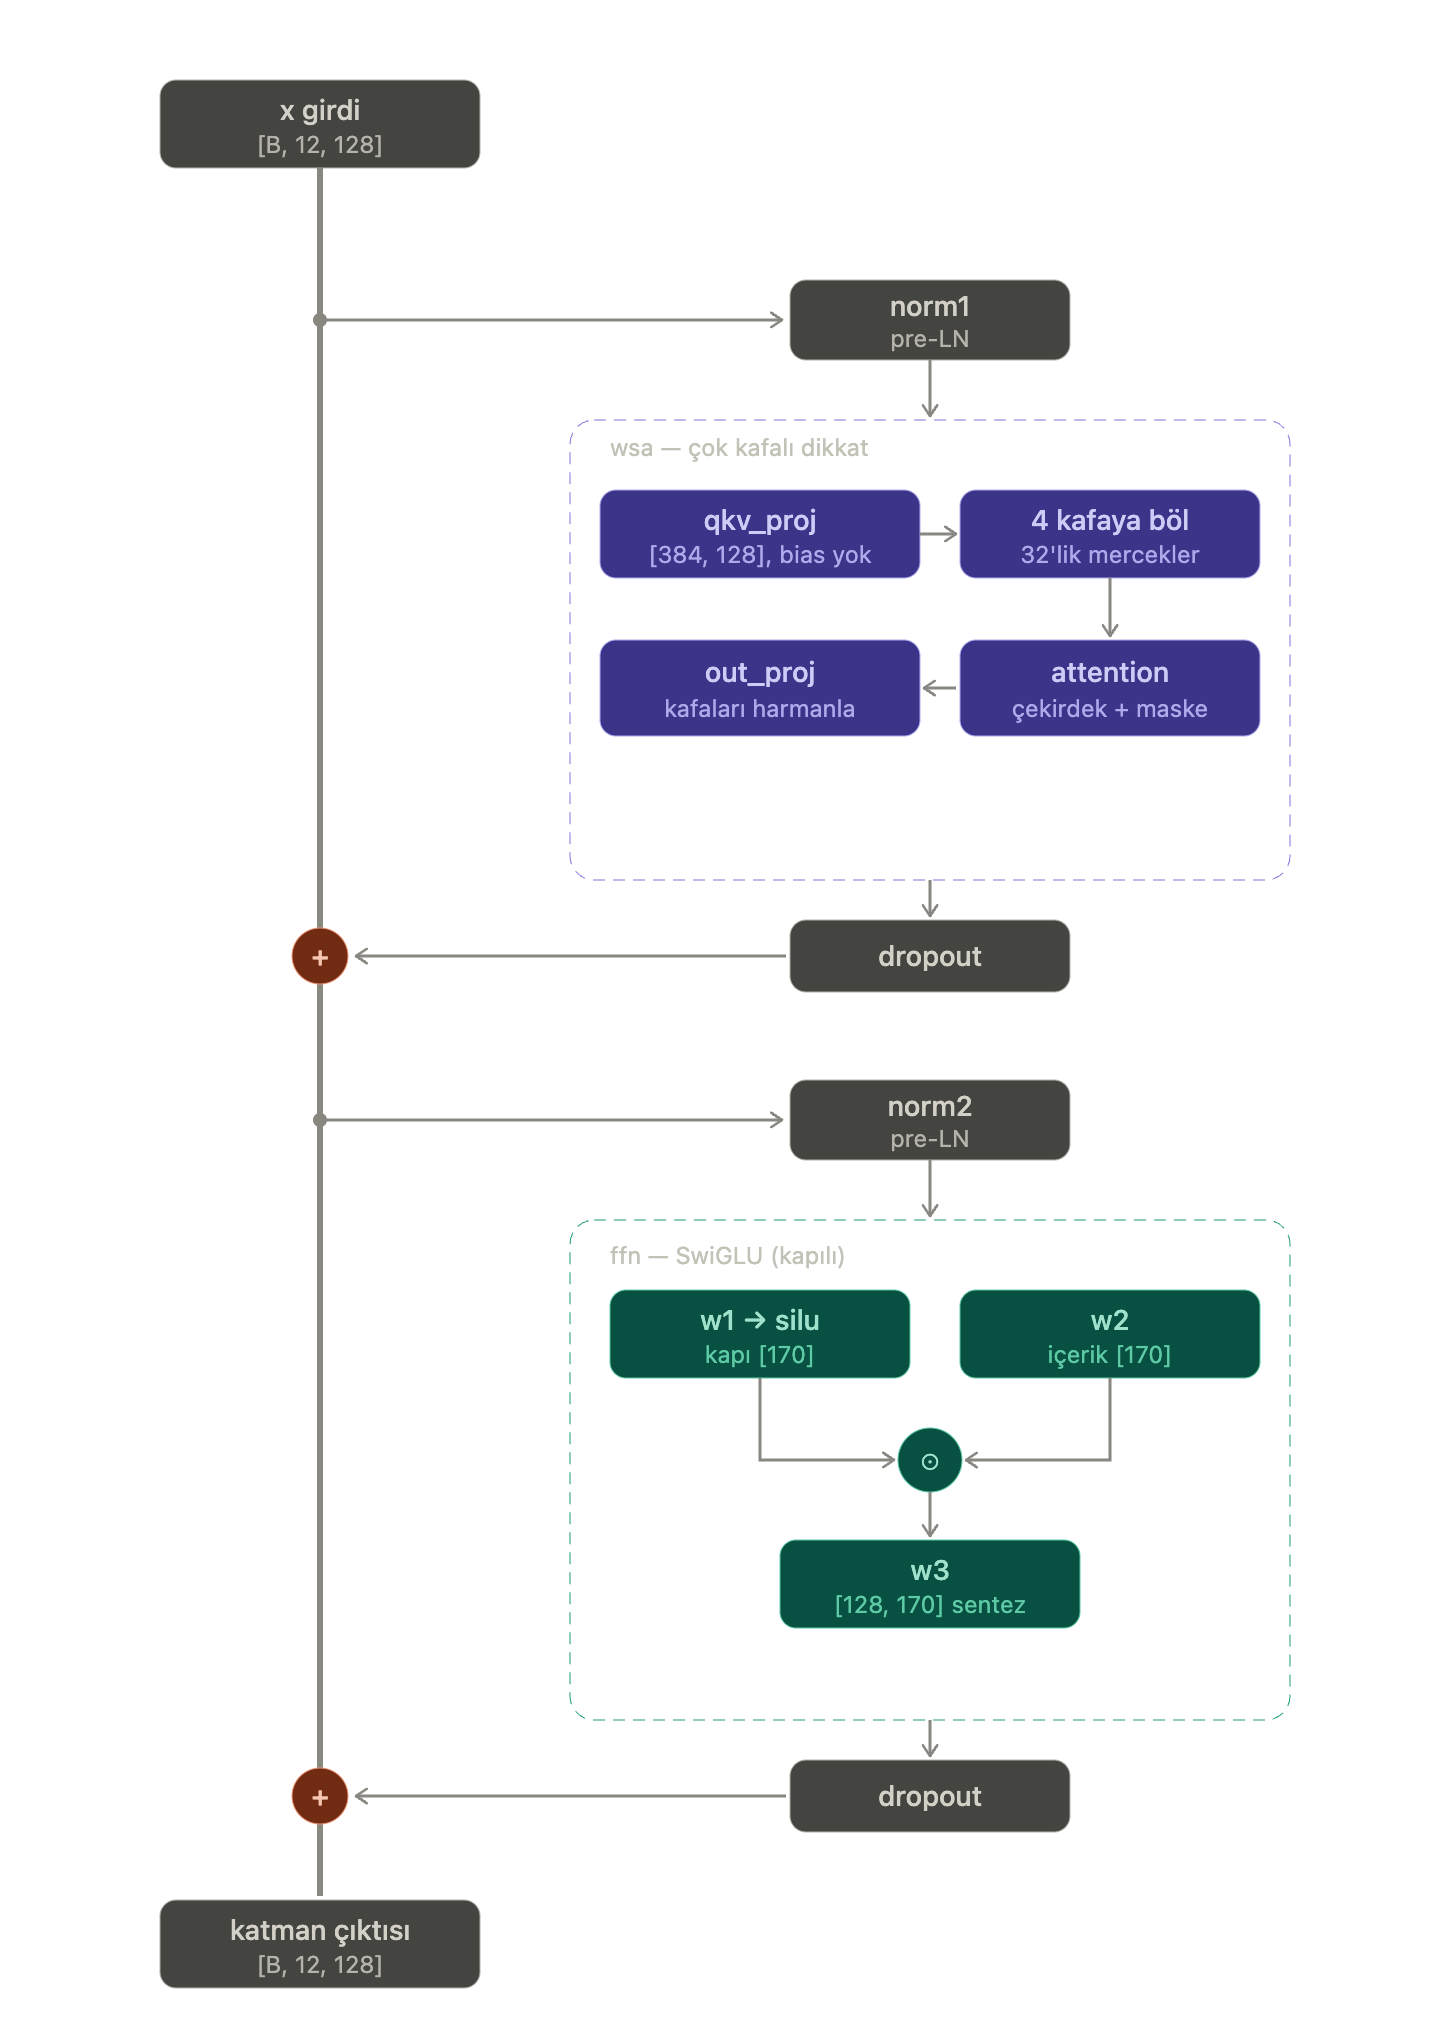

Ve bütün MST bu şeklin 4 kez üst üste konması — her tekrarda attention kutusundaki maske değişiyor (w=5, 15, 45, sonuncuda maske yok)

In [20]:
from huggingface_hub import hf_hub_download
import torch

file_path = hf_hub_download(
    repo_id = "smkim37/TripleSumm",
    filename="best_model_ckpt_mrhisum.pth",
    # repo_type="dataset"
)


print(type(torch.load(file_path, map_location="cpu", weights_only=True)))

sd = torch.load(file_path, map_location="cpu", weights_only=True) # indirdiğimiz checkpoint'i yükleyelim.

for i, k in sd.items():
  print(i, " shape: ", k.shape)


best_model_ckpt_mrhisum.pth: reconstructing file:   0%|          |  0.00B / 10.8MB            

best_model_ckpt_mrhisum.pth: downloading bytes:           |  0.00B            

<class 'collections.OrderedDict'>
visual_proj.weight  shape:  torch.Size([128, 1024])
visual_proj.bias  shape:  torch.Size([128])
text_proj.weight  shape:  torch.Size([128, 768])
text_proj.bias  shape:  torch.Size([128])
audio_proj.weight  shape:  torch.Size([128, 768])
audio_proj.bias  shape:  torch.Size([128])
visual_ln.weight  shape:  torch.Size([128])
visual_ln.bias  shape:  torch.Size([128])
text_ln.weight  shape:  torch.Size([128])
text_ln.bias  shape:  torch.Size([128])
audio_ln.weight  shape:  torch.Size([128])
audio_ln.bias  shape:  torch.Size([128])
temporal_pe.pe  shape:  torch.Size([1, 10000, 128])
modality_embedding.embedding.weight  shape:  torch.Size([4, 128])
temporal_block.0.wsa_layer.wsa.qkv_proj.weight  shape:  torch.Size([384, 128])
temporal_block.0.wsa_layer.wsa.out_proj.weight  shape:  torch.Size([128, 128])
temporal_block.0.wsa_layer.ffn.w1.weight  shape:  torch.Size([170, 128])
temporal_block.0.wsa_layer.ffn.w2.weight  shape:  torch.Size([170, 128])
temporal_blo

In [22]:
import torch.nn as nn
import torch

# linear(in, out) -> girdiyi çarpıp projekte eder.
# LayerNorm ise normalizasyon yapar, projeksiyon değil.

# burda sadece attention mekanizmasına sahip bir wsa var.
class WSA(nn.Module):
  def __init__(self, d_model, num_heads):
    super().__init__()

    self.num_heads = num_heads
    self.head_dim = d_model // num_heads # her head'e düşecek dilim - 32

    self.qkv_proj = nn.Linear(d_model, 3 * d_model, bias=False)
    # q, k, v diye 3 ayrı katman kurmak yerine 1 tane 3 katı kurup, 3'e böleriz.
    # böylece GPU tek seferde çok büyük matris çarpımı yaparak hızlanır

    self.out_proj = nn.Linear(d_model, d_model, bias=False)
    # bu yonetici kısım. 4 head'ten gelen verileri harmanlayıp, dısarıya duzenli
    # bir rapor verir.

  def forward(self, x, mask=None):
    x = self.qkv_proj(x) # [B, 12, 384]
    # x dev matrise giriyor ve her token için q,k, v vektörleri bitisik halde üretilir.

    Q, K, V = torch.chunk(x, 3, dim=-1) # Q, K, V -> her biri [B, 12 , 128]
    # burada büyük matrisi, özellik ekseninde (dim=-1) 3 böleriz ve q,k,v ortaya cıkar.

    out, attn_weights = multi_head_attention(Q, K, V, num_heads=self.num_heads, mask=mask)
    out = self.out_proj(out)
    return out, attn_weights



In [24]:
wsa = WSA(128, 4)
out, attn_weights = wsa(X, window_mask)
print(out.shape)
print(attn_weights.shape)

for name, p in wsa.state_dict().items():
  print(name, p.shape)

torch.Size([2, 12, 128])
torch.Size([2, 4, 12, 12])
qkv_proj.weight torch.Size([384, 128])
out_proj.weight torch.Size([128, 128])


In [27]:
import torch
import torch.nn as nn

# burada ise norm1 + WSA + norm2 + FFN bloğu olacak
# modern bir transformer mimarisinin bir katmanı
class WSALayer(nn.Module):
  def __init__(self, d_model, num_heads, dropout):
    super().__init__()
    self.wsa = WSA(d_model, num_heads) # tokenlar arası iletisim
    self.ffn = SwiGLU(d_model, dropout=dropout) #
    self.norm1 = nn.LayerNorm(d_model, bias=True) # Pre-LN düzeni için.
    self.norm2 = nn.LayerNorm(d_model, bias=True) # verinin ortalamasını 0'a, varyansını 1'e çeker.
    self.dropout = nn.Dropout(dropout) # Eğitim sırasında bazı bağlantıları rastgele kapatarak modelin ezber yapmasını (overfitting) engelleyen güvenlik katman

  def forward(self, x, mask=None):
    # residual connection yapacağız
    # Orjinal x elimizde beklerken, bir kopyasını norm1'den geçireceğiz ve wsa'ya sokacağız. - 1. otoyol
    attn_out, attn_weight = self.wsa(self.norm1(x), mask)

    # orjinal x ile wsa'nın cıktısını birbirine ekleriz - residual connection
    x = x + self.dropout(attn_out)

    # attention ile zenginleştirilmiş x bir kez daha normalizasyon için norm2'ye girer.
    # normalize edilmiş veri, SwiGLU'ya girer ve gate-içerek yollarından geçerek sindirilir.
    # ve bir kez daha residual connection
    x = x + self.dropout(self.ffn(self.norm2(x)))
    return x, attn_weight

In [30]:
layer = WSALayer(128, 4, 0.1)
out, attn = layer(X, window_mask)
print(out.shape)
print(attn.shape)
print(len(layer.state_dict()))

for name, p in layer.state_dict().items():
  print(name, tuple(p.shape))

print(torch.allclose(out, X))



torch.Size([2, 12, 128])
torch.Size([2, 4, 12, 12])
9
wsa.qkv_proj.weight (384, 128)
wsa.out_proj.weight (128, 128)
ffn.w1.weight (170, 128)
ffn.w2.weight (170, 128)
ffn.w3.weight (128, 170)
norm1.weight (128,)
norm1.bias (128,)
norm2.weight (128,)
norm2.bias (128,)
False


In [32]:


# out ve attn farkı olarak bir not:

# out - temsil, içerik vektörüdür. Boyut: [2, 12, 128]
# 2: Batch boyutu (2 farklı video/örnek)
# 12: Zaman / Kare sayısı (Sequence Length)
# 128: Zenginleştirilmiş bilgi boyutu (d_model)
# Bu, modelin ana isletim verisidir.
# Verimiz bu katmandan geçerken Attention ile komşularından bilgi topladı,
# SwiGLU ile bu bilgiyi sindirdi ve Residual otoyolu ile güçlendi.
# ağın içinde yolculuğa devam eden veri budur.


# attn - dikkat haritası. Boyut: [2, 4, 12, 12]
# 2: Batch boyutu
# 4: Kafa sayısı (Multi-Head)
# 12: Soru soran kare (i)
# 12: Cevap veren kare (j)
# Bu, modelin işlem yaparken "Nereye ne kadar odaklandığının" haritasıdır (Softmax matrisi).
# İçindeki sayılar 0.0 ile 1.0 arasındadır ve her satırın toplamı 1.0'dır.
# Bir sonraki katmana gitmez.
# Model 6. videoyu özetlerken en çok hangi saniyelere odaklandı?" sorusunun cevabını vermek için bu matrisi alıp Isı Haritası (Heatmap) çizersin.

kare_6_gunlugu = attn[0, 0, 5, :]
print(kare_6_gunlugu)


# "Model 6. saniyeyi işlerken;
# 4. saniyeye %10,
# 5. saniyeye %25,
# 6. saniyenin kendisine %50,
# 7. saniyeye %15 odaklandı.
# Diğer tüm saniyelere ise pencere maskesi yüzünden %0 ayırdı."
# gibi yorumlanır. bir nevi checkpoint gibi

# Bu yüzden yapay zeka araştırmalarında bir modelin
# "ırkçılık, cinsiyetçilik veya yanlış bilgi" üretip üretmediği
# ya da videonun hangi saniyesinden etkilendiği analiz edilirken
 # (Explainable AI / XAI) ilk bakılan yer tam olarak burasıdır.

tensor([0.0000, 0.0000, 0.0000, 0.1257, 0.2201, 0.1510, 0.3016, 0.2016, 0.0000,
        0.0000, 0.0000, 0.0000], grad_fn=<SelectBackward0>)
